### Spatio-Temporal Crime Prediction (for Violent Crime)
**Aim:** Predict the probability ($P$) that a crime will occur in a specific tile at a specific time. To direct patrol units (beats) to perform "proactive presence" in these specific tiles during their shift.

### Setup


In [79]:
# Install required packages (run once if needed)
!pip install geopandas h3 xgboost scikit-learn pandas numpy matplotlib seaborn joblib contextily --quiet

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
# Data manipulation
import pandas as pd
import numpy as np
import geopandas as gpd
import h3
from shapely.geometry import Polygon

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx # Added contextily import

# Math utilities
from math import radians  # For converting degrees to radians (used in Haversine formula)

# File I/O
import json
import joblib  # For saving/loading sklearn models
import os

# Machine Learning
import xgboost as xgb  # Gradient boosting library
from sklearn.ensemble import RandomForestClassifier  # Bagging ensemble method
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder  # For categorical encoding in pipelines
from sklearn.compose import ColumnTransformer  # Apply different transforms to different columns
from sklearn.pipeline import Pipeline  # Chain preprocessing + model together
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


---
### Step 1: Load Data

We load data from two parquet files (after DatasetDownload to local drive):
- **ChicagoCrimes(20152025).parquet**: Reported crime incidents in Chicago from 2015 to 2025 (crime types, locations, dates and arrest status)
- **ChicagoCommunityArea.parquet**: Geographic and administrative information of Chicago's 77 official community areas 
- **Chicago Police Beats Boundary (API)**: Current police beat boundaries in Chicago

In [12]:
from pathlib import Path
from shapely.geometry import shape

print("="*60)
print("STEP 1: LOAD DATA")
print("="*60)

# Resolve path relative to this notebook location
notebook_dir = Path.cwd()
base_dir = notebook_dir.parent.parent  # IT5006Group
project_data_dir = base_dir / "ProjectData"

community_path = project_data_dir / "chicagocommunityarea.parquet"
crimes_path = project_data_dir / "chicagocrimes(20152025).parquet"

if not community_path.exists() or not crimes_path.exists():
    raise FileNotFoundError(
        "Could not find one or both parquet files in ProjectData.\n"
        f"Expected:\n- {community_path}\n- {crimes_path}"
    )

print(f"\nLoading data from:\n  {community_path}\n  {crimes_path}")

# Load Chicago community area lookup table
community_df = pd.read_parquet(community_path)
print(f"   {community_path.name}: {len(community_df):,} rows")

# Load Chicago crimes main dataset
crimes_df = pd.read_parquet(crimes_path)
print(f"   {crimes_path.name}: {len(crimes_df):,} rows")

# Load Chicago Police Beats boundary dataset (SODA2 API endpoint from portal)
beats_url = "https://data.cityofchicago.org/resource/n9it-hstw.json?$limit=5000"
beats_df = pd.read_json(beats_url)

if "the_geom" in beats_df.columns:
    beats_gdf = gpd.GeoDataFrame(
        beats_df.drop(columns=["the_geom"]).copy(),
        geometry=beats_df["the_geom"].apply(lambda geom: shape(geom) if isinstance(geom, dict) else None),
        crs="EPSG:4326"
    )
else:
    beats_gdf = gpd.GeoDataFrame(beats_df.copy(), geometry=None)

print(f"   Chicago Police Beats (API): {len(beats_df):,} rows")
if "geometry" in beats_gdf.columns:
    print(f"   Beats with valid geometry: {beats_gdf.geometry.notna().sum():,}")

print("\nDataset Statistics:")
print(f"   Total crime records: {len(crimes_df):,}")

# # Calculate arres rate and domesticity - important for understanding class imbalanceumns are available
printed_any_rate = False

if "Arrest" in crimes_df.columns:
    arrest_rate = crimes_df["Arrest"].astype(bool).mean() * 100
    print(f"   Arrest=True: {crimes_df['Arrest'].astype(bool).sum():,} ({arrest_rate:.2f}%)")
    printed_any_rate = True

if "Domestic" in crimes_df.columns:
    domestic_rate = crimes_df["Domestic"].astype(bool).mean() * 100
    print(f"   Domestic=True: {crimes_df['Domestic'].astype(bool).sum():,} ({domestic_rate:.2f}%)")
    printed_any_rate = True

if not printed_any_rate:
    print("   No 'Arrest' or 'Domestic' column found; skipped label summary.")

STEP 1: LOAD DATA

Loading data from:
  c:\Users\tpi_5\Documents\Masters\4. IT5006 Data Analytics\IT5006Group\ProjectData\chicagocommunityarea.parquet
  c:\Users\tpi_5\Documents\Masters\4. IT5006 Data Analytics\IT5006Group\ProjectData\chicagocrimes(20152025).parquet
   chicagocommunityarea.parquet: 77 rows
   chicagocrimes(20152025).parquet: 2,755,021 rows
   Chicago Police Beats (API): 277 rows
   Beats with valid geometry: 277

Dataset Statistics:
   Total crime records: 2,755,021
   Arrest=True: 480,385 (17.44%)
   Domestic=True: 532,290 (19.32%)


In [13]:
# Preview the data
print("\n Sample crime records:")
crimes_df.head(3)


 Sample crime records:


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13711023,JJ103490,01/01/2015 12:00:00 AM,088XX S BISHOP ST,1261,DECEPTIVE PRACTICE,UNAUTHORIZED VIDEOTAPING,RESIDENCE,False,True,...,21.0,71.0,11,NaN,NaN,2015,01/05/2025 03:42:25 PM,NaN,NaN,None
1,13368845,JH152261,01/01/2015 12:00:00 AM,001XX N STATE ST,1150,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,DEPARTMENT STORE,False,False,...,34.0,32.0,11,NaN,NaN,2015,02/15/2024 03:40:52 PM,NaN,NaN,None
2,13448318,JH247450,01/01/2015 12:00:00 AM,010XX N LECLAIRE AVE,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,RESIDENCE,False,True,...,37.0,25.0,02,NaN,NaN,2015,05/03/2024 03:41:27 PM,NaN,NaN,None


In [14]:
# Preview the data
print("\n Sample community area data:")
community_df.head(3)


 Sample community area data:


,the_geom,AREA_NUMBE,COMMUNITY,AREA_NUM_1,SHAPE_AREA,SHAPE_LEN
0,MULTIPOLYGON (((-87.65455590025104 41.99816614...,1,ROGERS PARK,1,"51.259.902,4506","34.052,3975757"
1,MULTIPOLYGON (((-87.6846530946559 42.019484772...,2,WEST RIDGE,2,"98.429.094,8621","43.020,6894583"
2,MULTIPOLYGON (((-87.64102430213292 41.95480280...,3,UPTOWN,3,"65.095.642,7289","46.972,7945549"


In [15]:
# Preview the data
print("\n Sample beat data:")
beats_df.head(3)


 Sample beat data:


,the_geom,district,sector,beat,beat_num
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,1,1,1713
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31,0,0,3100
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",16,5,5,1651


---
### Step 2: Preprocess data (Filter, Clean, Grid)

- **Violent Crime** - targeting predictable violent crime, focused on primary type within top 10 offences: BATTERY, ASSAULT and ROBBERY
- **Last 3 years (Train) and Last 1 year (Test)** - avoiding 2020 and 2021 due to Covid-19, using 2022 to 2024 for training and 2025 for testing
- **Missing Data** - drop records with missing latitude, longitude, date and out of Chicago boundaries
- **Grid** - assign every crime incident to a tile ID and create master grid of (tile x date)

In [16]:
# Define violent crime labels
# violent_crimes = [
#     'HOMICIDE', 'BATTERY', 'ASSAULT', 'ROBBERY',
#     'CRIMINAL SEXUAL ASSAULT', 'CRIM SEXUAL ASSAULT',
#     'KIDNAPPING', 'HUMAN TRAFFICKING', 'STALKING', 'INTIMIDATION'
#  ]

violent_crimes = [
    'BATTERY', 'ASSAULT', 'ROBBERY']

# Create binary violent flag
crimes_df['is_violent'] = crimes_df['Primary Type'].isin(violent_crimes).astype(int)

# Keep only violent crime records
rows_before = len(crimes_df)
crimes_df = crimes_df[crimes_df['is_violent'] == 1].copy()
rows_after = len(crimes_df)

print("Filtered to violent crimes only")
print(f"Rows before: {rows_before:,}")
print(f"Rows after : {rows_after:,}")
print(f"Removed    : {rows_before - rows_after:,}")
print("\nPrimary Type counts (violent only):")
print(crimes_df['Primary Type'].value_counts())

Filtered to violent crimes only
Rows before: 2,755,021
Rows after : 828,741
Removed    : 1,926,280

Primary Type counts (violent only):
Primary Type
BATTERY    503679
ASSAULT    223180
ROBBERY    101882
Name: count, dtype: int64


In [18]:
# Filter to records from years 2022, 2023, 2024 and 2025
# Assumes crimes_df is already loaded

rows_before = len(crimes_df)

target_years = [2022, 2023, 2024, 2025]
crimes_df = crimes_df[crimes_df["Year"].isin(target_years)].copy()
rows_after = len(crimes_df)

print("Filtered crimes_df successfully")
print(f"Rows before: {rows_before:,}")
print(f"Rows after : {rows_after:,}")
print(f"Removed    : {rows_before - rows_after:,}")
print(f"Kept years : {target_years}")

Filtered crimes_df successfully
Rows before: 297,247
Rows after : 297,247
Removed    : 0
Kept years : [2022, 2023, 2024, 2025]


In [19]:
# Drop records with missing Latitude, Longitude, or Date,
# then keep only rows within Chicago city bounds
# Assumes crimes_df is already loaded and filtered

# Ensure Date is datetime so invalid dates become NaT
crimes_df["Date"] = pd.to_datetime(crimes_df["Date"], errors="coerce")

rows_before = len(crimes_df)

# 1) Drop missing geo/date values
crimes_df = crimes_df.dropna(subset=["Latitude", "Longitude", "Date"]).copy()
rows_after_dropna = len(crimes_df)

# 2) Keep only coordinates within Chicago limits
chicago_mask = (
    (crimes_df["Latitude"] > 41.6) & (crimes_df["Latitude"] < 42.1) &
    (crimes_df["Longitude"] > -88.0) & (crimes_df["Longitude"] < -87.5)
)
crimes_df = crimes_df[chicago_mask].copy()
rows_after_bounds = len(crimes_df)

print("Cleaned crimes_df successfully")
print(f"Rows before cleaning        : {rows_before:,}")
print(f"After dropping missing vals : {rows_after_dropna:,}")
print(f"After Chicago bounds filter : {rows_after_bounds:,}")
print(f"Total removed              : {rows_before - rows_after_bounds:,}")

Cleaned crimes_df successfully
Rows before cleaning        : 297,247
After dropping missing vals : 296,425
After Chicago bounds filter : 296,424
Total removed              : 823


In [20]:
# Build H3 features from the current crimes_df
# Assumes crimes_df already contains cleaned Latitude, Longitude, and Date

RESOLUTION = 8  # Higher number = smaller hexagons e.g. 8 is ~0.7km^2 area

# Assign H3 cell id to each record
crimes_df["h3_address"] = crimes_df.apply(
    lambda row: h3.latlng_to_cell(row["Latitude"], row["Longitude"], RESOLUTION),
    axis=1
)

# Aggregate crimes per tile per day (this becomes model input)
# Grouping by Tile and Date (for daily probability)
df_h3 = crimes_df.copy()
df_h3["Date"] = df_h3["Date"].dt.date
tile_counts = (
    df_h3.groupby(["h3_address", "Date"]).size().reset_index(name="crime_count")
)

# Convert H3 cells to polygons for mapping
def h3_to_polygon(hex_id):
    boundary = h3.cell_to_boundary(hex_id)  # (lat, lng)
    return Polygon([(lng, lat) for lat, lng in boundary])

gdf_tiles = gpd.GeoDataFrame(
    tile_counts,
    geometry=tile_counts["h3_address"].apply(h3_to_polygon),
    crs="EPSG:4326"
)

print(f"H3 feature table created at resolution {RESOLUTION}")
print(f"Crime records used: {len(df_h3):,}")
print(f"Tile-day rows: {len(tile_counts):,}")
print(f"Unique tiles: {tile_counts['h3_address'].nunique():,}")
gdf_tiles.head()

H3 feature table created at resolution 8
Crime records used: 296,424
Tile-day rows: 230,050
Unique tiles: 857


,h3_address,Date,crime_count,geometry
0,8826641903fffff,2022-02-23,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
1,8826641903fffff,2022-04-05,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
2,8826641903fffff,2022-06-20,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
3,8826641903fffff,2022-07-25,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
4,8826641903fffff,2022-11-08,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."


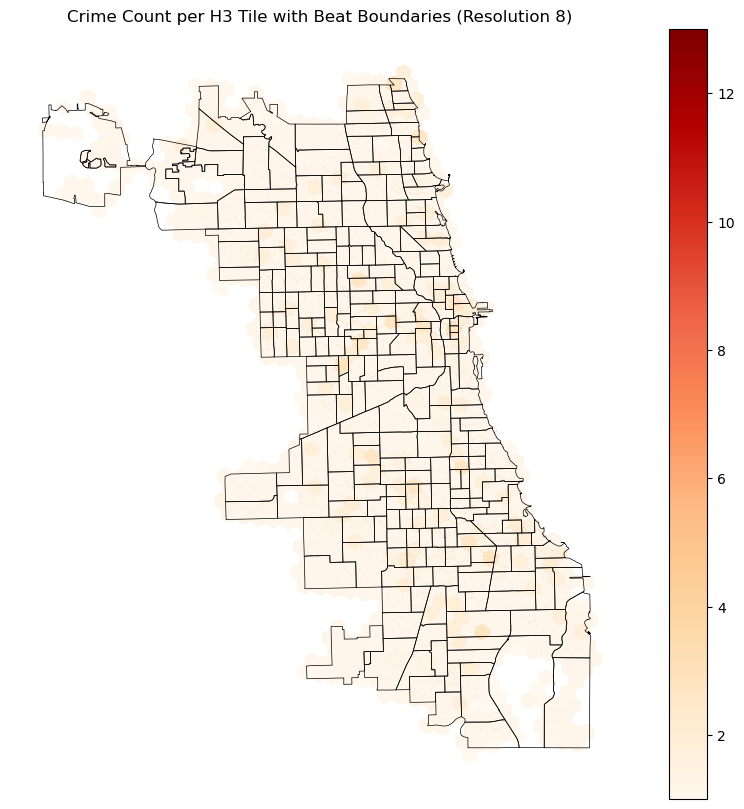

In [21]:
# Plot H3 crime intensity and overlay Chicago Beat boundaries
fig, ax = plt.subplots(figsize=(10, 10))

# Base layer: H3 tiles
gdf_tiles.to_crs("EPSG:4326").plot(
    column="crime_count",
    cmap="OrRd",
    legend=True,
    ax=ax,
    alpha=0.75
)

# Overlay: beat boundaries
beats_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

ax.set_title(f"Crime Count per H3 Tile with Beat Boundaries (Resolution {RESOLUTION})")
ax.set_axis_off()
plt.show()

In [30]:
# Create target variable by adding tile-shifts where crime did not happen (zero crime)
# Shift bins: morning/noon (06:00-14:00), afternoon/night (14:00-22:00), overnight (22:00-06:00)

# Ensure datetime
df_shift = crimes_df.copy()
df_shift["Date"] = pd.to_datetime(df_shift["Date"], errors="coerce")
df_shift = df_shift.dropna(subset=["Date", "h3_address"]).copy()

# 1) Assign each record to a shift and a shift_date (anchored to shift start date)
hour = df_shift["Date"].dt.hour
df_shift["shift"] = np.select(
    [hour.between(6, 13), hour.between(14, 21)],
    ["morning_noon", "afternoon_night"],
    default="overnight"
)

# For 00:00-05:59, the shift started the previous day at 22:00
df_shift["shift_date"] = df_shift["Date"].dt.floor("D")
df_shift.loc[hour < 6, "shift_date"] = df_shift.loc[hour < 6, "shift_date"] - pd.Timedelta(days=1)

# 2) Aggregate crimes per tile per shift
tile_shift_counts = (
    df_shift.groupby(["h3_address", "shift_date", "shift"]).size().reset_index(name="crime_count")
)

# 3) Create master grid: every (tile x date x shift)
all_h3_tiles = df_shift["h3_address"].unique()
all_shift_dates = pd.date_range(
    start=df_shift["shift_date"].min(),
    end=df_shift["shift_date"].max(),
    freq="D"
 )
shift_order = ["morning_noon", "afternoon_night", "overnight"]

index = pd.MultiIndex.from_product(
    [all_h3_tiles, all_shift_dates, shift_order],
    names=["h3_address", "shift_date", "shift"]
)
master_grid = pd.DataFrame(index=index).reset_index()

# 4) Merge actual counts onto master grid
final_df = pd.merge(
    master_grid,
    tile_shift_counts,
    on=["h3_address", "shift_date", "shift"],
    how="left"
 )

# 5) Fill no-crime shifts with 0 and create binary target
final_df["crime_count"] = final_df["crime_count"].fillna(0)
final_df["target"] = (final_df["crime_count"] > 0).astype(int)

# 6) Keep a Date column for downstream steps (shift start timestamp)
shift_start_hour = {"morning_noon": 6, "afternoon_night": 14, "overnight": 22}
final_df["Date"] = final_df["shift_date"] + pd.to_timedelta(final_df["shift"].map(shift_start_hour), unit="h")

In [31]:
# Preview the shift-level master grid
print("\nSample master grid (8-hour shifts):")
preview_cols = ["h3_address", "shift_date", "shift", "crime_count", "target", "Date"]
final_df[preview_cols].head(10)


Sample master grid (8-hour shifts):


,h3_address,shift_date,shift,crime_count,target,Date
0,882664cccbfffff,2021-12-31,morning_noon,0.0,0,2021-12-31 06:00:00
1,882664cccbfffff,2021-12-31,afternoon_night,0.0,0,2021-12-31 14:00:00
2,882664cccbfffff,2021-12-31,overnight,1.0,1,2021-12-31 22:00:00
3,882664cccbfffff,2022-01-01,morning_noon,0.0,0,2022-01-01 06:00:00
4,882664cccbfffff,2022-01-01,afternoon_night,0.0,0,2022-01-01 14:00:00
5,882664cccbfffff,2022-01-01,overnight,0.0,0,2022-01-01 22:00:00
6,882664cccbfffff,2022-01-02,morning_noon,0.0,0,2022-01-02 06:00:00
7,882664cccbfffff,2022-01-02,afternoon_night,0.0,0,2022-01-02 14:00:00
8,882664cccbfffff,2022-01-02,overnight,1.0,1,2022-01-02 22:00:00
9,882664cccbfffff,2022-01-03,morning_noon,0.0,0,2022-01-03 06:00:00


---
### Step 3: Feature Engineering
- **1-Day Lag**: what happened yesterday?
- **7-Day Rolling Average**: what is the recent situation in the last week? Captures short-term volatility. 
- **30-Day Rolling Average**: what is the long-term baseline risk for this area? Identifies sticky hotspots that persists regardless of the day.[Removed because model is heavily reliant on this. Focus on 1-Day and 7-Day to make model more sensitive to recent waves.]
- **Day Sin/Cos**: Weekly patterns
- **Month Sin/Cos**: Monthly patterns
- **Weekend Flag**: Is this a Saturday or Sunday? Human behaviour shifts on weekends. 
- **1-Day Spatial Lag (Neighbour)**: What happened nearby yesterday?

In [36]:
# Ensure Date is datetime and sort within each tile
final_df['Date'] = pd.to_datetime(final_df['Date'])
final_df = final_df.sort_values(['h3_address', 'Date'])

In [37]:
# 1-Day Lag: What happened yesterday?
final_df['lag_1d'] = final_df.groupby('h3_address')['crime_count'].shift(1)

# Rolling Averages: The 'Momentum' of the tile
# min_periods=1 ensures we get a value even if the window isn't full yet
# use shift(1) to avoid data leakage (don't include current day in the average)
final_df['rolling_7d_mean'] = (
    final_df.groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

final_df['rolling_30d_mean'] = (
    final_df.groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)

In [38]:
# Cyclical time features: Encode day of week and month as sine/cosine pairs to capture cyclical patterns without introducing artificial discontinuities
# Extract basic components
final_df['day_of_week'] = final_df['Date'].dt.dayofweek
final_df['month'] = final_df['Date'].dt.month

# Sine/Cosine Transformation for Day of Week (0-6)
# Sunday (6) is adjacent to Monday (0)
final_df['day_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7)

# Sine/Cosine Transformation for Month (1-12)
# Subtract 1 from month to make it 0-11 for the transformation, so December (12) is adjacent to January (1)
final_df['month_sin'] = np.sin(2 * np.pi * (final_df['month']-1) / 12)
final_df['month_cos'] = np.cos(2 * np.pi * (final_df['month']-1) / 12)

In [39]:
# Weekend flag
final_df['is_weekend'] = final_df['day_of_week'].isin([5, 6]).astype(int)

# Drop any NaNs created by the shift (usually the first few rows of each tile)
final_df = final_df.dropna()

In [70]:
# Binary flag for overnight shift risk
# Is it a high-risk time? (Night shift is usually 22:00 - 06:00)
final_df['is_night_shift'] = (final_df['shift'] == 'overnight').astype(int)

In [72]:
# Simple Seasonal Darkness Proxy 
# Chicago: Winter months (Nov, Dec, Jan, Feb) have more dark hours in Shift 1 (Afternoon)
final_df['is_winter_evening'] = (
    (final_df['month'].isin([11, 12, 1, 2])) & 
    (final_df['shift'] == 'afternoon_night')
).astype(int)

In [74]:
# Cyclical Shift encoding based on current shift labels
shift_to_idx = {'morning_noon': 0, 'afternoon_night': 1, 'overnight': 2}
shift_idx = final_df['shift'].map(shift_to_idx).fillna(0)

final_df['shift_sin'] = np.sin(2 * np.pi * shift_idx / 3)
final_df['shift_cos'] = np.cos(2 * np.pi * shift_idx / 3)

In [ ]:
# Spatial lag feature from neighboring H3 tiles
import h3

def get_neighbor_stats(df):
    # 1) Create a lookup for crime counts by (Date, h3_address)
    # Dictionary lookup is O(1) and scales better on large data
    yesterday_lookup = df.set_index(['Date', 'h3_address'])['crime_count'].to_dict()

    def calc_spatial_lag(row):
        # Find central tile + its 1-ring neighbors (up to 6)
        neighbors = h3.grid_disk(row['h3_address'], k=1)
        neighbors = [n for n in neighbors if n != row['h3_address']]

        neighbor_counts = []
        for n in neighbors:
            # Look up what happened in this neighbor for the same Date index
            count = yesterday_lookup.get((row['Date'], n), 0)
            neighbor_counts.append(count)

        return sum(neighbor_counts)

    # 2) Apply row-wise to create spatial lag feature
    # Note: this may take a few minutes on very large datasets (took about 4 minutes)
    df['neighbor_lag_1d'] = df.apply(calc_spatial_lag, axis=1)

    return df

final_df = get_neighbor_stats(final_df)

In [75]:
# Preview engineered features except Weekend flag (categorical flag is less interesting in a describe() summary)
feature_cols = ['lag_1d', 'rolling_7d_mean', 'rolling_30d_mean',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 
                'is_night_shift', 'is_winter_evening', 'shift_sin', 'shift_cos',
                'neighbor_lag_1d']
print("\n--- Engineered Features Preview ---")
final_df[feature_cols].describe().round(2)


--- Engineered Features Preview ---


,lag_1d,rolling_7d_mean,rolling_30d_mean,day_sin,day_cos,month_sin,month_cos,is_night_shift,is_winter_evening,shift_sin,shift_cos,neighbor_lag_1d
count,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00,3757088.00
mean,0.08,0.08,0.08,-0.00,0.00,-0.00,-0.00,0.33,0.11,-0.00,-0.00,0.46
std,0.30,0.14,0.10,0.71,0.71,0.71,0.71,0.47,0.31,0.71,0.71,0.82
min,0.00,0.00,0.00,-0.97,-0.90,-1.00,-1.00,0.00,0.00,-0.87,-0.50,0.00
25%,0.00,0.00,0.00,-0.78,-0.90,-0.50,-0.87,0.00,0.00,-0.87,-0.50,0.00
50%,0.00,0.00,0.03,0.00,-0.22,0.00,-0.00,0.00,0.00,0.00,-0.50,0.00
75%,0.00,0.14,0.11,0.78,0.62,0.87,0.50,1.00,0.00,0.87,1.00,1.00
max,13.00,2.86,2.00,0.97,1.00,1.00,1.00,1.00,1.00,0.87,1.00,22.00


In [76]:
final_df.head()

,h3_address,shift_date,shift,crime_count,target,Date,lag_1d,rolling_7d_mean,rolling_30d_mean,day_of_week,...,day_sin,day_cos,month_sin,month_cos,is_weekend,neighbor_lag_1d,is_night_shift,is_winter_evening,shift_sin,shift_cos
3109676,8826641903fffff,2021-12-31,overnight,0.0,0,2021-12-31 22:00:00,0.0,0.0,0.0,4,...,-0.433884,-0.900969,-0.5,0.866025,0,0.0,1,0,-0.866025,-0.5
3109677,8826641903fffff,2022-01-01,morning_noon,0.0,0,2022-01-01 06:00:00,0.0,0.0,0.0,5,...,-0.974928,-0.222521,0.0,1.000000,1,0.0,0,0,0.000000,1.0
3109678,8826641903fffff,2022-01-01,afternoon_night,0.0,0,2022-01-01 14:00:00,0.0,0.0,0.0,5,...,-0.974928,-0.222521,0.0,1.000000,1,0.0,0,1,0.866025,-0.5
3109679,8826641903fffff,2022-01-01,overnight,0.0,0,2022-01-01 22:00:00,0.0,0.0,0.0,5,...,-0.974928,-0.222521,0.0,1.000000,1,0.0,1,0,-0.866025,-0.5
3109680,8826641903fffff,2022-01-02,morning_noon,0.0,0,2022-01-02 06:00:00,0.0,0.0,0.0,6,...,-0.781831,0.623490,0.0,1.000000,1,0.0,0,0,0.000000,1.0


---
### Step 4: Prepare Training Data

In [ ]:
print("="*60)
print("STEP 4: PREPARE TRAINING DATA WITH PIPELINE")
print("="*60)

# =============================================================================
# DEFINE FEATURE COLUMNS
# Separating categorical vs numeric is important for ColumnTransformer
# =============================================================================
CATEGORICAL_COLS = ['is_weekend']  # Will be ordinally encoded
NUMERIC_COLS = [
    'lag_1d',               # 1-day lag of crime count
    'rolling_7d_mean',      # 7-day rolling average of crime count
    'day_sin',              # day of week encoded as sine
    'day_cos',              # day of week encoded as cosine
    'month_sin',            # month encoded as sine
    'month_cos',            # month encoded as cosine
    'is_night_shift',      # Binary flag for night shift
    'is_winter_evening',   # Binary flag for winter evening shift
    'shift_sin',           # Shift encoded as sine
    'shift_cos',           # Shift encoded as cosine
    'neighbor_lag_1d'       # 1-day lag of neighboring tiles' crime count
]
FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS
LABEL_COL = 'target'

print(f"\nFeature columns ({len(FEATURE_COLS)} total):")
print(f"   Categorical: {CATEGORICAL_COLS}")
print(f"   Numeric: {NUMERIC_COLS}")

# Drop rows with missing values
df = final_df.dropna(subset=FEATURE_COLS + [LABEL_COL]).copy()
print(f"\n   Samples after dropping NaN: {len(df):,}")

STEP 4: PREPARE TRAINING DATA WITH PIPELINE

Feature columns (8 total):
   Categorical: ['is_weekend']
   Numeric: ['lag_1d', 'rolling_7d_mean', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'neighbor_lag_1d']

   Samples after dropping NaN: 3,757,088


In [59]:
# =============================================================================
# CREATE PREPROCESSING PIPELINE (ColumnTransformer)
# =============================================================================
# ColumnTransformer applies different transformations to different column types:
# - Categorical columns: OrdinalEncoder (converts strings to integers)
# - Numeric columns: 'passthrough' (no transformation needed)
#
# WHY THIS MATTERS:
# - Prevents data leakage: encoder is fit ONLY on training data
# - Ensures consistency: same encoding applied during inference
# - Clean deployment: single pipeline object to save/load

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         CATEGORICAL_COLS),  # Encode 'category' column
        ('num', 'passthrough', NUMERIC_COLS)  # Keep numeric columns as-is
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessor created:")
print("   ColumnTransformer with:")
print("   - OrdinalEncoder for categorical columns")
print("   - Passthrough for numeric columns")
print("\n   Note: Preprocessor will be fit inside the Pipeline (after train/test split)")

Preprocessor created:
   ColumnTransformer with:
   - OrdinalEncoder for categorical columns
   - Passthrough for numeric columns

   Note: Preprocessor will be fit inside the Pipeline (after train/test split)


In [60]:
# =============================================================================
# TRAIN-TEST SPLIT BY YEAR (time-aware split to avoid temporal leakage)
# =============================================================================
# Train: 2022-2024, Test: 2025

# Ensure Date column is datetime for year filtering
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Build year-based masks
train_years = [2022, 2023, 2024]
test_year = 2025

train_mask = df['Date'].dt.year.isin(train_years)
test_mask = df['Date'].dt.year.eq(test_year)

# Prepare X (raw features - NOT encoded yet) and y (target)
X_train = df.loc[train_mask, FEATURE_COLS]
y_train = df.loc[train_mask, LABEL_COL]

X_test = df.loc[test_mask, FEATURE_COLS]
y_test = df.loc[test_mask, LABEL_COL]

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError(
        f"Empty split detected. Train rows: {len(X_train)}, Test rows: {len(X_test)}. "
        "Check year filters and upstream preprocessing."
    )

print("\nData split complete (time-based, BEFORE preprocessing):")
print(f"   Training years: {train_years}")
print(f"   Test year: {test_year}")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% positive)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% positive)")
print("\n   Note: X contains raw features - preprocessing happens inside Pipeline")


Data split complete (time-based, BEFORE preprocessing):
   Training years: [2022, 2023, 2024]
   Test year: 2025
   Training: 2,817,816 samples (7.20% positive)
   Test:     938,415 samples (6.69% positive)

   Note: X contains raw features - preprocessing happens inside Pipeline


---
### Step 5: Train Ensemble Models with Pipelines

We create **complete pipelines** that include:
1. **Preprocessor** (ColumnTransformer) - handles categorical encoding
2. **Model** (XGBoost or Random Forest)

In [61]:
print("="*60)
print("STEP 5: TRAIN ENSEMBLE MODELS")
print("="*60)

# Calculate class weight for imbalanced data
# This tells the model: "zero samples are X times more important"
# Aim: to give the minority class more "weight" without losing data, instead of downsampling or SMOTE.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance: {scale_pos_weight:.1f}:1 (no crime:crime)")
print(f"   Using class weighting to handle imbalance")

STEP 5: TRAIN ENSEMBLE MODELS

Class imbalance: 12.9:1 (no crime:crime)
   Using class weighting to handle imbalance


In [62]:
# =========================================================================
# PIPELINE 1: Preprocessor + XGBoost
# Pipeline chains: ColumnTransformer -> XGBoost
# =========================================================================
import time

print("\n" + "-"*40)
print("Training XGBoost Pipeline...")
print("-"*40)

# Create XGBoost model
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds (trees)
    max_depth=6,                # Maximum tree depth (controls complexity)
    learning_rate=0.1,          # Step size shrinkage (prevents overfitting)
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Create Pipeline: preprocessor -> model
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Step 1: Transform features
    ('classifier', xgb_classifier)   # Step 2: Train model
])

# Fit the entire pipeline (preprocessor + model) on training data
start_time = time.perf_counter()
xgb_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time

print("   XGBoost Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")
print(f"   Time taken: {elapsed:.2f} seconds")


----------------------------------------
Training XGBoost Pipeline...
----------------------------------------
   XGBoost Pipeline trained!
   Pipeline steps: preprocessor -> classifier
   Time taken: 4.98 seconds


In [63]:
# =========================================================================
# PIPELINE 2: Preprocessor + Random Forest
# Note: We need a fresh copy of preprocessor (sklearn clones it anyway)
# =========================================================================
print("\n" + "-"*40)
print("Training Random Forest Pipeline...")
print("-"*40)

# Create Random Forest model
rf_classifier = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum tree depth
    class_weight='balanced',    # Auto-adjust weights inversely to class freq
    random_state=42,
    n_jobs=-1                   # Use all CPU cores for parallel training
)

# Create Pipeline with a fresh preprocessor
# (Each pipeline needs its own preprocessor to avoid conflicts)
from sklearn.base import clone
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),  # Fresh copy of preprocessor
    ('classifier', rf_classifier)
])

# Fit the entire pipeline
start_time = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time

print("   Random Forest Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")
print(f"   Time taken: {elapsed:.2f} seconds")


----------------------------------------
Training Random Forest Pipeline...
----------------------------------------
   Random Forest Pipeline trained!
   Pipeline steps: preprocessor -> classifier
   Time taken: 27.07 seconds


---
## Step 6: Evaluate Models

Evaluate using multiple metrics because accuracy alone is misleading for imbalanced data:
- **Accuracy**: Overall correct predictions (misleading if 99% are legit)
- **Precision**: Of predicted frauds, how many are real? (avoid false alarms)
- **Recall**: Of actual frauds, how many did we catch? (don't miss fraud!)
- **F1 Score**: Balance between precision and recall
- **ROC AUC**: Model's ability to rank fraud higher than legit

In [ ]:
print("="*60)
print("STEP 6: EVALUATE PIPELINES")
print("="*60)

def evaluate_pipeline(pipeline, X_test, y_test, name):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of crime

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{name} Pipeline Results:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1 Score:  {metrics['f1_score']:.4f}")
    print(f"   ROC AUC:   {metrics['roc_auc']:.4f}")

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test, "XGBoost")
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest")

STEP 6: EVALUATE PIPELINES

XGBoost Pipeline Results:
   Accuracy:  0.6438
   Precision: 0.1152
   Recall:    0.6467
   F1 Score:  0.1955
   ROC AUC:   0.6885

Random Forest Pipeline Results:
   Accuracy:  0.6342
   Precision: 0.1138
   Recall:    0.6575
   F1 Score:  0.1940
   ROC AUC:   0.6882


XGBoost Brier Score     : 0.2133
Random Forest Brier Score: 0.2137


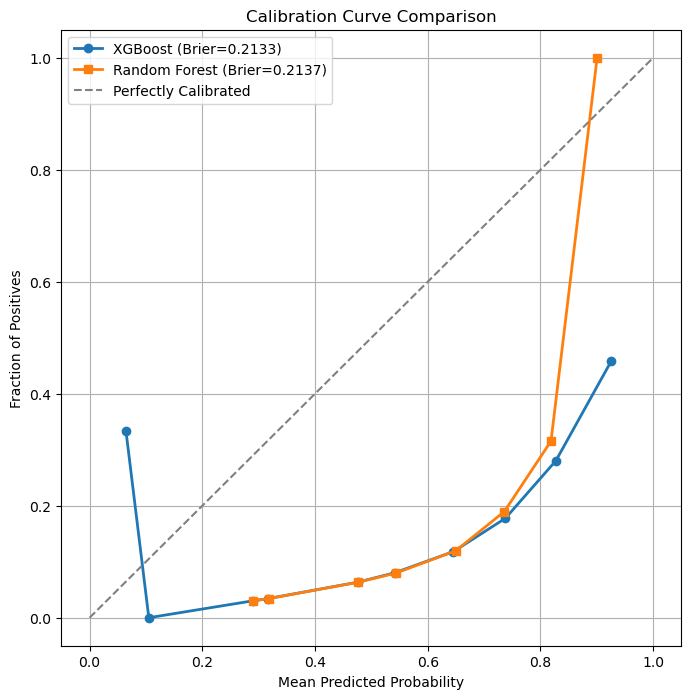

In [68]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Predicted probabilities
xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]

# Calibration curve points
xgb_true, xgb_pred = calibration_curve(y_test, xgb_probs, n_bins=10)
rf_true, rf_pred = calibration_curve(y_test, rf_probs, n_bins=10)

# Brier scores (lower is better)
xgb_brier = brier_score_loss(y_test, xgb_probs)
rf_brier = brier_score_loss(y_test, rf_probs)

print(f"XGBoost Brier Score     : {xgb_brier:.4f}")
print(f"Random Forest Brier Score: {rf_brier:.4f}")

# Plot both reliability curves
plt.figure(figsize=(8, 8))
plt.plot(xgb_pred, xgb_true, marker='o', linewidth=2, label=f'XGBoost (Brier={xgb_brier:.4f})')
plt.plot(rf_pred, rf_true, marker='s', linewidth=2, label=f'Random Forest (Brier={rf_brier:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

---
### Misc: Feature and Permutation Importance (using XGB)

Aim to understand what the various predictors mean to the model and whether any feature should be removed.

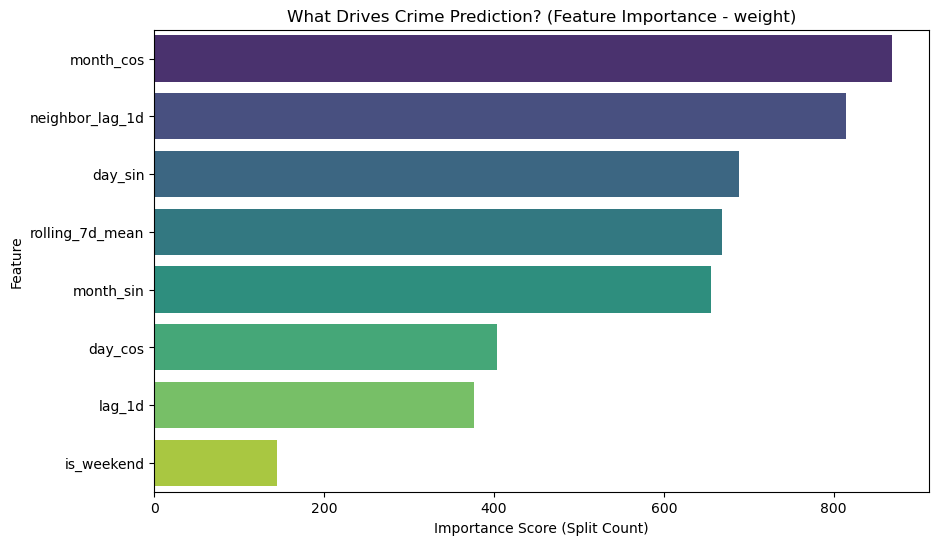

,Feature,Importance
6,month_cos,869.0
7,neighbor_lag_1d,814.0
3,day_sin,688.0
2,rolling_7d_mean,668.0
5,month_sin,655.0
4,day_cos,404.0
1,lag_1d,377.0
0,is_weekend,145.0


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract fitted XGBoost model and feature names from pipeline
if 'xgb_pipeline' not in globals():
    raise ValueError("xgb_pipeline not found. Run the model training cell first.")

if 'classifier' in xgb_pipeline.named_steps:
    xgb_model = xgb_pipeline.named_steps['classifier']
elif 'xgb' in xgb_pipeline.named_steps:
    xgb_model = xgb_pipeline.named_steps['xgb']
else:
    raise ValueError(f"Could not find XGBoost step in pipeline. Steps: {list(xgb_pipeline.named_steps.keys())}")

feature_names = list(X_train.columns)

# 2. Get importance scores from booster ('weight' = split count, instead of default gain)
raw_importances = xgb_model.get_booster().get_score(importance_type='weight')

# Map f0, f1, ... to real feature names and fill missing with 0
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': [raw_importances.get(f'f{i}', 0.0) for i in range(len(feature_names))]
}).sort_values(by='Importance', ascending=False)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('What Drives Crime Prediction? (Feature Importance - weight)')
plt.xlabel('Importance Score (Split Count)')
plt.ylabel('Feature')
plt.show()

feat_imp_df

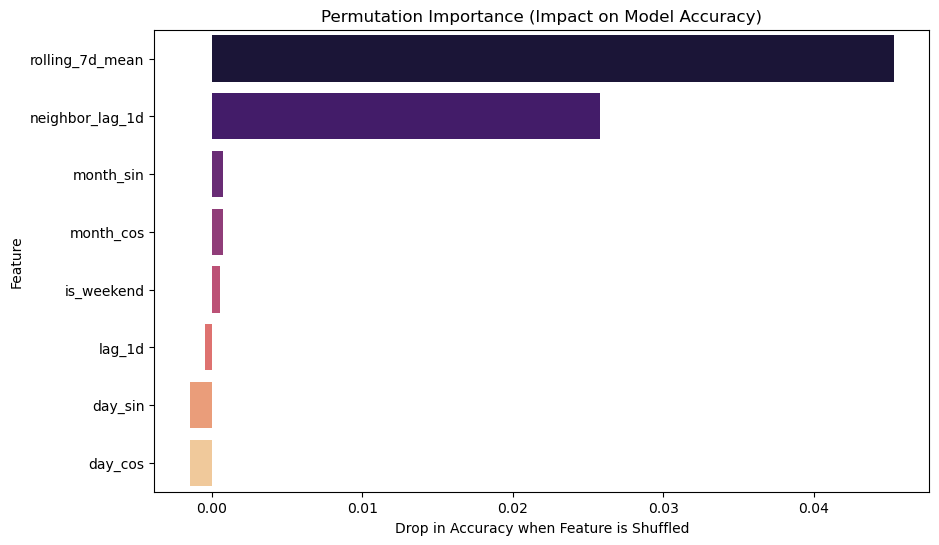

In [66]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Permutation Importance
# n_repeats=5 means it shuffles each column 5 times to get a stable average
result = permutation_importance(
    xgb_pipeline, X_test, y_test, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1
)

# 2. Organize the results into a DataFrame
perm_imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_imp_df, palette='magma')
plt.title('Permutation Importance (Impact on Model Accuracy)')
plt.xlabel('Drop in Accuracy when Feature is Shuffled')
plt.show()